# Final Integrated Face Recognition Project
Dishan
This notebook combines four face recognition algorithms:
1. **MobileFaceNet** (Deep Learning)
2. **EfficientNet-B0** (Fine-tuned Deep Learning)
3. **PCA (Eigenfaces)** (Statistical)
4. **LBPH** (Local Binary Patterns Histogram)

It includes:
- **Face Detection**: BlazeFace (via MediaPipe)
- **Alignment**: Eye/Mouth normalization
- **Preprocessing**: Specific resizing and normalization per model
- **Augmentation**: Flipping, Rotation, Color Jittering
- **Validation**: Rank-1 Accuracy, ROC/AUC, and Comparative Analysis



In [1]:
# Install necessary packages (if not already installed)
#!pip install torch torchvision opencv-python scikit-learn matplotlib mediapipe pandas seaborn



In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import mediapipe as mp
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
from pytorch_metric_learning import losses
from collections import OrderedDict
import time
import math
import seaborn as sns

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# GLOBAL CONFIG
DATASET_ROOT = 'VGGFace2'  # Update this to your dataset path, e.g., 'd:/AI coursework/dataset/CelebA-20251209T060012Z-1-001/CelebA'
NUM_CLASSES_TO_USE = 50    # Subsetting for demo speed, increase for full training
BATCH_SIZE = 32



Using device: cuda


## 1. Face Detection & Alignment (BlazeFace)
Using MediaPipe Tasks API (replacing legacy solutions) to detect faces and align them based on eye positions.
**Note**: This requires the `detector.tflite` model file.



In [3]:
import urllib.request

# Download model if not present
if not os.path.exists('detector.tflite'):
    print("Downloading BlazeFace model...")
    url = "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite"
    urllib.request.urlretrieve(url, 'detector.tflite')
    print("Download complete.")

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

class FaceAligner:
    def __init__(self, model_path='detector.tflite'):
        # Create an FaceDetector object.
        base_options = python.BaseOptions(model_asset_path=model_path)
        options = vision.FaceDetectorOptions(base_options=base_options)
        self.detector = vision.FaceDetector.create_from_options(options)

        # Standard reference points for 112x112 (ArcFace)
        # Left Eye, Right Eye, Nose
        self.ref_points_112 = np.array([
            [38.2946, 51.6963], # Left Eye
            [73.5318, 51.5014], # Right Eye
            [56.0252, 71.7366]  # Nose
        ], dtype=np.float32)

    def align_face(self, image_path, target_size=(112, 112)):
        # target_size is (W, H)
        
        try:
            mp_image = mp.Image.create_from_file(image_path)
            detection_result = self.detector.detect(mp_image)
        except Exception:
            return None

        image_np = mp_image.numpy_view()
        
        if not detection_result.detections:
            # Fallback: Center Crop and Resize
            h, w = image_np.shape[:2]
            # Simple center square crop
            short_dim = min(h, w)
            start_x = (w - short_dim) // 2
            start_y = (h - short_dim) // 2
            cropped = image_np[start_y:start_y+short_dim, start_x:start_x+short_dim]
            return cv2.resize(cropped, target_size)
        
        # Use first detection
        detection = detection_result.detections[0]
        kp = detection.keypoints # 0: Right Eye, 1: Left Eye, 2: Nose
        
        # MediaPipe gives normalized coords [0, 1]
        h, w = image_np.shape[:2]
        
        # Extract source points: Left Eye, Right Eye, Nose
        # Note: MediaPipe Keypoint 0 is RIGHT EYE (User's Right, Image Left if selfie? No, MP is Reader's Right?)
        # Let's verify: 
        # MP Doc: 0 - Right Eye, 1 - Left Eye. 
        # CAUTION: "Right Eye" usually means the person's right eye. In a frontal view, that is on the LEFT of the image.
        # ArcFace Ref: Point 0 is Left Eye (38.29), Point 1 is Right Eye (73.53).
        # So we want to map:
        # MP Keypoint 1 (Person's Left Eye, on Image Right) -> Ref Point 1 (Right side of 112 image, 73.53)
        # MP Keypoint 0 (Person's Right Eye, on Image Left) -> Ref Point 0 (Left side of 112 image, 38.29)
        # Wait, if Ref Point 0 is 38.29 (Left side of image), that corresponds to the Person's Right Eye.
        
        # Let's assume standard "Left Eye" in Ref Points means "Eye on the Left side of the image".
        # 38.29 is < 56 (center), so it's on the Left.
        # Person's Right Eye is on the Left of the image.
        # MP Keypoint 0 is Right Eye.
        # So: MP(0) -> Ref(0)
        #     MP(1) -> Ref(1)
        #     MP(2) -> Ref(2) (Nose)
        
        src_pts = np.array([
            [kp[0].x * w, kp[0].y * h], # Person Right Eye (Image Left)
            [kp[1].x * w, kp[1].y * h], # Person Left Eye (Image Right)
            [kp[2].x * w, kp[2].y * h]  # Nose
        ], dtype=np.float32)
        
        # Scale reference points if target is not 112x112
        ref_pts = self.ref_points_112.copy()
        if target_size != (112, 112):
            scale_x = target_size[0] / 112.0
            scale_y = target_size[1] / 112.0
            ref_pts[:, 0] *= scale_x
            ref_pts[:, 1] *= scale_y
            
        # Affine Transform
        M = cv2.getAffineTransform(src_pts, ref_pts)
        aligned = cv2.warpAffine(image_np, M, target_size)
        
        return aligned

# Instantiate global aligner
aligner = FaceAligner()



## 2. Dataset Loading & Preprocessing
We define custom Datasets to handle the specific requirements:
- **Resizing**: 112x112 (MFN/PCA), 224x224 (EffNet), 80x80 (LBPH)
- **Normalization**: [-1, 1] vs HistEq
- **Augmentation**: Horizontal Flip, Rotation, Color Jitter



In [4]:
class UnifiedFaceDataset(Dataset):
    def __init__(self, file_paths, labels, mode='train', model_type='mobilefacenet'):
        self.file_paths = file_paths
        self.labels = labels
        self.mode = mode
        self.model_type = model_type  # 'mobilefacenet', 'efficientnet', 'lbph', 'pca'
        
        # Definitions needed for initialization
        self.aligner = FaceAligner()
        
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label = self.labels[idx]
        
        # 1. Detection & Alignment (and resizing)
        if self.model_type == 'efficientnet':
            target_size = (224, 224)
        elif self.model_type == 'lbph':
            target_size = (80, 80)
        else: # mobilefacenet and pca
            target_size = (112, 112)
            
        # We use our custom aligner which returns a numpy array (RGB)
        # Note: In a real training loop, doing face detection every epoch is slow. 
        # Ideally, preprocess dataset offline. Here we do it on-the-fly or fallback to simple resize for speed.
        try:
            # Use full blaze face pipeline (Face Detection + Alignment + Resize)
            img_arr = self.aligner.align_face(path, target_size)
            
            # Fallback if something returned None (e.g. file error)
            if img_arr is None:
                img = Image.open(path).convert('RGB')
                img_arr = np.array(img.resize(target_size))
                
        except Exception as e:
            # Fallback
            img = Image.new('RGB', target_size)
            img_arr = np.array(img)

        # 2. Augmentation & Normalization
        # Setup specific to model
        if self.model_type == 'lbph':
            # Grayscale + HistEq
            img_gray = cv2.cvtColor(img_arr, cv2.COLOR_RGB2GRAY) if img_arr.ndim==3 else img_arr
            img_gray = cv2.equalizeHist(img_gray)
            return img_gray, label
            
        elif self.model_type == 'pca':
            # Grayscale + Flatten + Normalize [-1, 1]
            img_gray = cv2.cvtColor(img_arr, cv2.COLOR_RGB2GRAY) if img_arr.ndim==3 else img_arr
            img_flat = img_gray.flatten().astype(np.float32)
            img_norm = (img_flat - 127.5) / 128.0
            return img_norm, label
            
        else: # Deep Learning (MFN, EffNet)
            # Convert back to PIL for Torchvision transforms if desired, or use ToTensor
            img_pil = Image.fromarray(img_arr)
            
            if self.mode == 'train':
                transform_list = [
                    transforms.RandomHorizontalFlip(),
                    transforms.RandomRotation(15),
                    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # [-1, 1]
                ]
            else:
                transform_list = [
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
                ]
            
            tf = transforms.Compose(transform_list)
            return tf(img_pil), label



## 3. Model Architectures
Defining the four models to be used.



In [5]:
# --- 1. MobileFaceNet ---
class Bottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, expansion, stride):
        super().__init__()
        expanded_channels = in_channels * expansion
        self.use_residual = stride == 1 and in_channels == out_channels
        self.conv1 = nn.Conv2d(in_channels, expanded_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(expanded_channels)
        self.prelu1 = nn.PReLU(expanded_channels)
        self.dwconv = nn.Conv2d(expanded_channels, expanded_channels, kernel_size=3, stride=stride, padding=1, groups=expanded_channels, bias=False)
        self.bn2 = nn.BatchNorm2d(expanded_channels)
        self.prelu2 = nn.PReLU(expanded_channels)
        self.conv3 = nn.Conv2d(expanded_channels, out_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = self.prelu1(self.bn1(self.conv1(x)))
        out = self.prelu2(self.bn2(self.dwconv(out)))
        out = self.bn3(self.conv3(out))
        if self.use_residual: out = out + x
        return out

class MobileFaceNet(nn.Module):
    def __init__(self, embedding_size=512, num_classes=None):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.prelu1 = nn.PReLU(64)
        self.dwconv1 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, groups=64, bias=False)
        self.bn_dw1 = nn.BatchNorm2d(64)
        self.prelu_dw1 = nn.PReLU(64)
        self.bottlenecks = nn.Sequential(
            Bottleneck(64, 64, expansion=2, stride=2),
            *[Bottleneck(64, 64, expansion=2, stride=1) for _ in range(4)],
            Bottleneck(64, 128, expansion=4, stride=2),
            *[Bottleneck(128, 128, expansion=2, stride=1) for _ in range(6)],
            Bottleneck(128, 128, expansion=4, stride=2),
            *[Bottleneck(128, 128, expansion=2, stride=1) for _ in range(2)],
        )
        self.conv_last = nn.Conv2d(128, 512, kernel_size=1, bias=False)
        self.bn_last = nn.BatchNorm2d(512)
        self.prelu_last = nn.PReLU(512)
        self.gdconv = nn.Conv2d(512, 512, kernel_size=7, groups=512, bias=False)
        self.bn_gd = nn.BatchNorm2d(512)
        self.linear = nn.Linear(512, embedding_size, bias=False)
        self.bn_embed = nn.BatchNorm1d(embedding_size)
    
    def forward(self, x):
        out = self.prelu1(self.bn1(self.conv1(x)))
        out = self.prelu_dw1(self.bn_dw1(self.dwconv1(out)))
        out = self.bottlenecks(out)
        out = self.prelu_last(self.bn_last(self.conv_last(out)))
        out = self.bn_gd(self.gdconv(out))
        out = out.view(out.size(0), -1)
        out = self.bn_embed(self.linear(out))
        return out

# --- 2. EfficientNet-B0 ---
class EfficientNetArcFace(nn.Module):
    def __init__(self, embedding_size=1280):
        super().__init__()
        # Use simple backbone
        self.backbone = models.efficientnet_b0(pretrained=True).features
        self.pool = nn.AdaptiveAvgPool2d(1)
        # EfficientNet-B0 features output 1280 channels
        self.embedding_size = embedding_size
        
    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x).flatten(1)
        return x

# --- 3. PCA (Eigenfaces) ---
class PCAModel:
    def __init__(self, n_components=150):
        self.n_components = n_components
        self.mean_face = None
        self.eigenfaces = None
        self.projections = None
        self.labels = None

    def fit(self, X, y):
        print("Training PCA...")
        self.mean_face = np.mean(X, axis=0)
        X_centered = X - self.mean_face
        
        # Covariance strategy depends on N vs D. Here assuming N < D usually for faces
        # Using SVD for stability
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
        self.eigenfaces = Vt[:self.n_components]
        
        # Project training data
        self.projections = np.dot(X_centered, self.eigenfaces.T)
        self.labels = y
        print("PCA Training Complete.")

    def predict(self, X):
        # Predict 1-NN
        X_centered = X - self.mean_face
        proj = np.dot(X_centered, self.eigenfaces.T)
        
        preds = []
        for p in proj:
            dists = np.linalg.norm(self.projections - p, axis=1)
            min_idx = np.argmin(dists)
            preds.append(self.labels[min_idx])
        return np.array(preds)
    
    def get_embeddings(self, X):
        X_centered = X - self.mean_face
        return np.dot(X_centered, self.eigenfaces.T)

# --- 4. LBPH is handled by OpenCV ---



In [6]:
# Prepare Data Paths
if not os.path.exists(DATASET_ROOT):
    print(f"Warning: Dataset path '{DATASET_ROOT}' not found. Please set DATASET_ROOT correctly.")
else:
    full_dataset = datasets.ImageFolder(DATASET_ROOT)
    targets = np.array(full_dataset.targets)
    
    # Filter subset
    classes_to_use = np.unique(targets)[:NUM_CLASSES_TO_USE]
    indices = np.where(np.isin(targets, classes_to_use))[0]
    
    selected_paths = [full_dataset.samples[i][0] for i in indices]
    selected_labels = targets[indices]
    
    # Remap labels to 0..N-1
    unique_lbls = np.unique(selected_labels)
    lbl_map = {orig: new for new, orig in enumerate(unique_lbls)}
    selected_labels = np.array([lbl_map[l] for l in selected_labels])
    
    # Stratified Split
    train_paths, test_paths, y_train, y_test = train_test_split(
        selected_paths, selected_labels, test_size=0.2, random_state=42, stratify=selected_labels
    )
    
    print(f"Train files: {len(train_paths)}")
    print(f"Test files: {len(test_paths)}")



Train files: 17997
Test files: 4500


## 2.1 Data Visualization
Here we visualize the dataset characteristics and preprocessing steps.



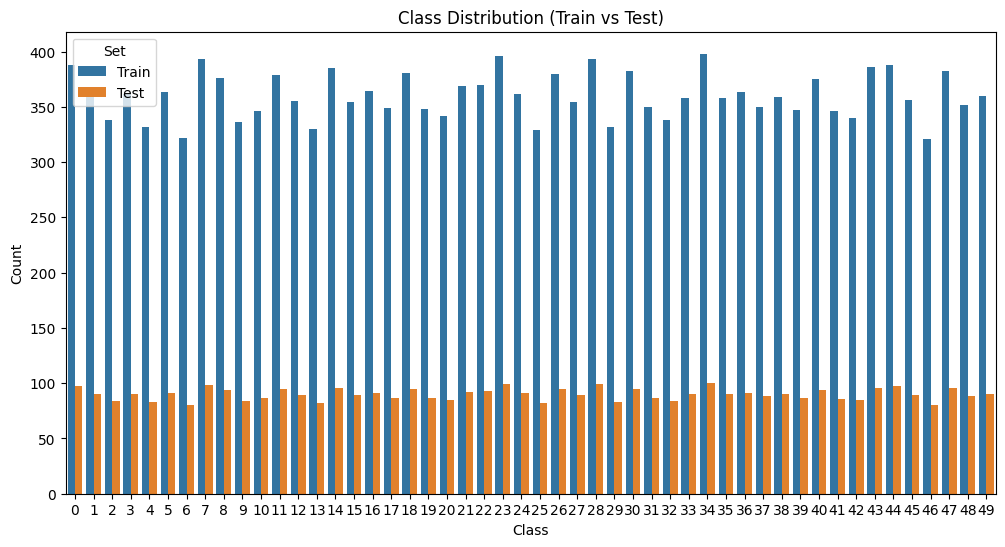

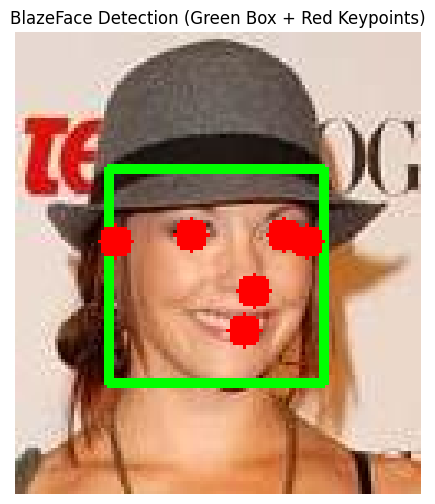

Visualizing Augmentation (MobileFaceNet Pipeline)...


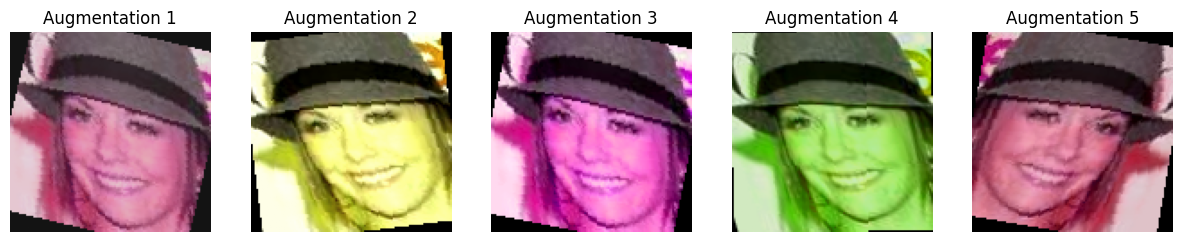

In [7]:
# 1. Class Distribution
plt.figure(figsize=(12, 6))
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

# Create DataFrame for plotting
import pandas as pd
df_train = pd.DataFrame({'Class': unique_train, 'Count': counts_train, 'Set': 'Train'})
df_test = pd.DataFrame({'Class': unique_test, 'Count': counts_test, 'Set': 'Test'})
df_counts = pd.concat([df_train, df_test])

sns.barplot(data=df_counts, x='Class', y='Count', hue='Set')
plt.title('Class Distribution (Train vs Test)')
plt.show()

# 2. BlazeFace Detection Visualization
def visualize_detection(image_path):
    if not os.path.exists(image_path): return
    
    # Use the aligner's detector
    mp_image = mp.Image.create_from_file(image_path)
    detection_result = aligner.detector.detect(mp_image)
    
    img_display = cv2.imread(image_path)
    img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
    
    if detection_result.detections:
        for detection in detection_result.detections:
            bbox = detection.bounding_box
            start_point = (bbox.origin_x, bbox.origin_y)
            end_point = (bbox.origin_x + bbox.width, bbox.origin_y + bbox.height)
            cv2.rectangle(img_display, start_point, end_point, (0, 255, 0), 2)
            
            # Keypoints
            for kp in detection.keypoints:
                x = int(kp.x * img_display.shape[1])
                y = int(kp.y * img_display.shape[0])
                cv2.circle(img_display, (x, y), 5, (255, 0, 0), -1)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_display)
    plt.title("BlazeFace Detection (Green Box + Red Keypoints)")
    plt.axis('off')
    plt.show()

# Visualize a random training image
if len(train_paths) > 0:
    visualize_detection(train_paths[0])

# 3. Augmentation Visualization
print("Visualizing Augmentation (MobileFaceNet Pipeline)...")
# Create a temp dataset in train mode
aug_ds = UnifiedFaceDataset(train_paths[:1], y_train[:1], mode='train', model_type='mobilefacenet')
plt.figure(figsize=(15, 3))
for i in range(5):
    img_tensor, _ = aug_ds[0] # Returns tensor C,H,W
    # Denormalize for display: [-1,1] -> [0,1]
    img = img_tensor.permute(1, 2, 0).numpy() * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(f"Augmentation {i+1}")
    plt.axis('off')
plt.show()



In [8]:
results = {}
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

def evaluate_features(train_embs, train_labels, test_embs, test_labels, model_name):
    print(f"Evaluating features for {model_name}...")
    
    # Normalize
    train_embs = train_embs / np.linalg.norm(train_embs, axis=1, keepdims=True)
    test_embs = test_embs / np.linalg.norm(test_embs, axis=1, keepdims=True)
    
    # 1. Identification (Rank-1 Accuracy & Confusion Matrix)
    # Use 1-NN Classifier as a proxy for Identification
    knn = KNeighborsClassifier(n_neighbors=1, metric='cosine')
    knn.fit(train_embs, train_labels)
    y_pred = knn.predict(test_embs)
    
    acc = accuracy_score(test_labels, y_pred)
    cm = confusion_matrix(test_labels, y_pred)
    
    # 2. Verification (Pairwise AUC)
    n_pairs = 3000
    sims, true_labels_pairs = [], []
    unique_cls = np.unique(test_labels)
    
    # Optimize pair generation
    for _ in range(n_pairs):
        if np.random.rand() > 0.5: # Same
            c = np.random.choice(unique_cls)
            idxs = np.where(test_labels == c)[0]
            if len(idxs) < 2: continue
            i, j = np.random.choice(idxs, 2, replace=False)
            sims.append(np.dot(test_embs[i], test_embs[j]))
            true_labels_pairs.append(1)
        else: # Diff
            c1, c2 = np.random.choice(unique_cls, 2, replace=False)
            i = np.random.choice(np.where(test_labels == c1)[0])
            j = np.random.choice(np.where(test_labels == c2)[0])
            sims.append(np.dot(test_embs[i], test_embs[j]))
            true_labels_pairs.append(0)
            
    auc_score = roc_auc_score(true_labels_pairs, sims)
    fpr, tpr, _ = roc_curve(true_labels_pairs, sims)
    
    return {'auc': auc_score, 'acc': acc, 'fpr': fpr, 'tpr': tpr, 'cm': cm, 'y_true': test_labels, 'y_pred': y_pred}

def train_eval_dl_model(model_class, name, embedding_size, img_size_mode):
    print(f"\n=== Processing {name} ===")
    
    # Datasets
    train_ds = UnifiedFaceDataset(train_paths, y_train, mode='train', model_type=img_size_mode)
    test_ds = UnifiedFaceDataset(test_paths, y_test, mode='test', model_type=img_size_mode)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # For extraction
    train_ds_eval = UnifiedFaceDataset(train_paths, y_train, mode='test', model_type=img_size_mode)
    train_eval_dl = DataLoader(train_ds_eval, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Model
    model = model_class(embedding_size=embedding_size).to(device)
    metric_fc = losses.ArcFaceLoss(num_classes=NUM_CLASSES_TO_USE, embedding_size=embedding_size).to(device)
    optimizer = optim.SGD([{'params': model.parameters()}, {'params': metric_fc.parameters()}], lr=0.01, momentum=0.9)
    
    # Train Loop (Short for demo)
    epochs = 50 
    model.train()
    for ep in range(epochs):
        loss_val = 0
        for imgs, lbls in train_dl:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            emb = model(imgs)
            loss = metric_fc(emb, lbls)
            loss.backward()
            optimizer.step()
            loss_val += loss.item()
        print(f"Feature Extractor {name}: Epoch {ep+1} Loss: {loss_val/len(train_dl):.4f}")
        
    # Create output dir
    os.makedirs('final_models', exist_ok=True)
    save_path = os.path.join('final_models', f"{name}.pth")
    torch.save(model.state_dict(), save_path)
    print(f"Saved {name} model to {save_path}")

    # Extract Embeddings (Train & Test)
    model.eval()
    def extract(loader):
        embs, lbls = [], []
        with torch.no_grad():
            for imgs, l in loader:
                embs.append(model(imgs.to(device)).cpu().numpy())
                lbls.append(l.numpy())
        return np.concatenate(embs), np.concatenate(lbls)

    train_embs, train_lbls_out = extract(train_eval_dl)
    test_embs, test_lbls_out = extract(test_dl)
    
    res = evaluate_features(train_embs, train_lbls_out, test_embs, test_lbls_out, name)
    results[name] = res
    print(f"{name} Verification AUC: {res['auc']:.4f}, Rank-1 Acc: {res['acc']:.4f}")
    return model



In [ ]:
# 1. MobileFaceNet
_ = train_eval_dl_model(MobileFaceNet, "MobileFaceNet", 512, 'mobilefacenet')

# 2. EfficientNet
_ = train_eval_dl_model(lambda embedding_size: EfficientNetArcFace(embedding_size), "EfficientNet", 1280, 'efficientnet')




=== Processing MobileFaceNet ===


In [ ]:
# Prepare Data arrays
def load_data_array(mode, model_type):
    ds = UnifiedFaceDataset(train_paths if mode=='train' else test_paths, 
                            y_train if mode=='train' else y_test, 
                            mode='test', 
                            model_type=model_type)
    data = []
    labels = []
    for i in range(len(ds)):
        d, l = ds[i]
        data.append(d)
        labels.append(l)
    return np.array(data), np.array(labels)

# --- 3. PCA ---
print("\n=== Processing PCA ===")
X_train_pca, Y_train_pca = load_data_array('train', 'pca')
X_test_pca, Y_test_pca = load_data_array('test', 'pca')

pca = PCAModel(n_components=150)
pca.fit(X_train_pca, Y_train_pca)

# Save PCA
os.makedirs('final_models', exist_ok=True)
np.savez('final_models/pca_model.npz', 
         mean=pca.mean_face, 
         eigenfaces=pca.eigenfaces, 
         projections=pca.projections, 
         labels=pca.labels)
print("Saved PCA model to final_models/pca_model.npz")

train_embs_pca = pca.get_embeddings(X_train_pca)
test_embs_pca = pca.get_embeddings(X_test_pca)
res_pca = evaluate_features(train_embs_pca, Y_train_pca, test_embs_pca, Y_test_pca, "PCA")
results["PCA"] = res_pca
print(f"PCA Verification AUC: {res_pca['auc']:.4f}")

# --- 4. LBPH ---
print("\n=== Processing LBPH ===")
X_train_lbph, Y_train_lbph = load_data_array('train', 'lbph')
X_test_lbph, Y_test_lbph = load_data_array('test', 'lbph')

lbph = cv2.face.LBPHFaceRecognizer_create()
lbph.train(X_train_lbph, Y_train_lbph)

# Save LBPH
lbph.write('final_models/lbph_model.yml')
print("Saved LBPH model to final_models/lbph_model.yml")

y_pred_lbph = []
for img in X_test_lbph:
    p_lbl, _ = lbph.predict(img)
    y_pred_lbph.append(p_lbl)
    
acc_lbph = accuracy_score(Y_test_lbph, y_pred_lbph)
cm_lbph = confusion_matrix(Y_test_lbph, y_pred_lbph)

results["LBPH"] = {
    'auc': 0.0, 'acc': acc_lbph, 'fpr': [0, 1], 'tpr': [0, 1], 
    'cm': cm_lbph, 'y_true': Y_test_lbph, 'y_pred': y_pred_lbph
}
print(f"LBPH Rank-1 Accuracy: {acc_lbph:.4f}")




=== Processing PCA ===
Training PCA...
PCA Training Complete.
Saved PCA model to final_models/pca_model.npz
Evaluating features for PCA...
PCA Verification AUC: 0.6051

=== Processing LBPH ===
Saved LBPH model to final_models/lbph_model.yml
LBPH Rank-1 Accuracy: 0.8930


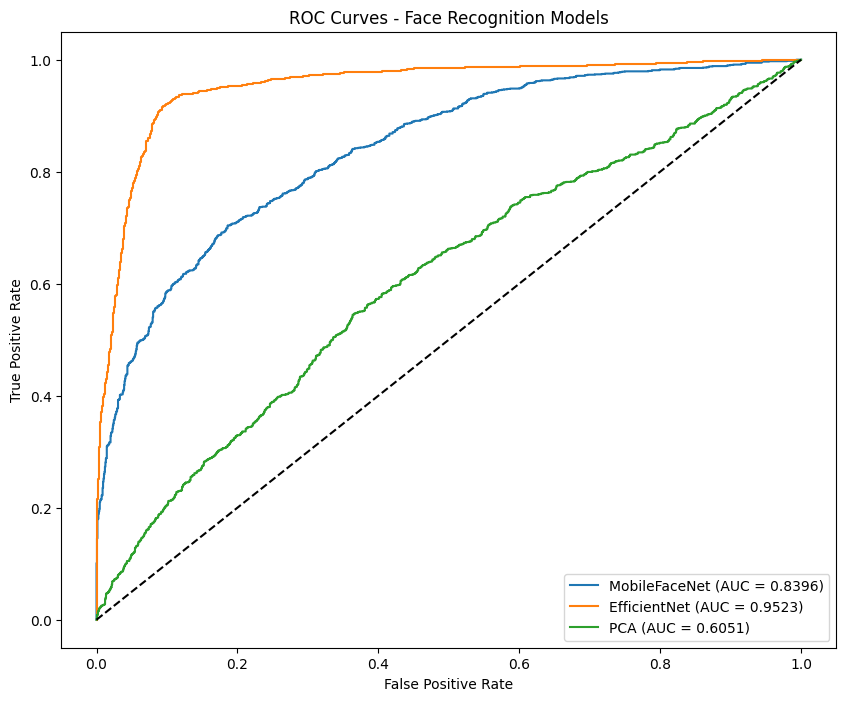

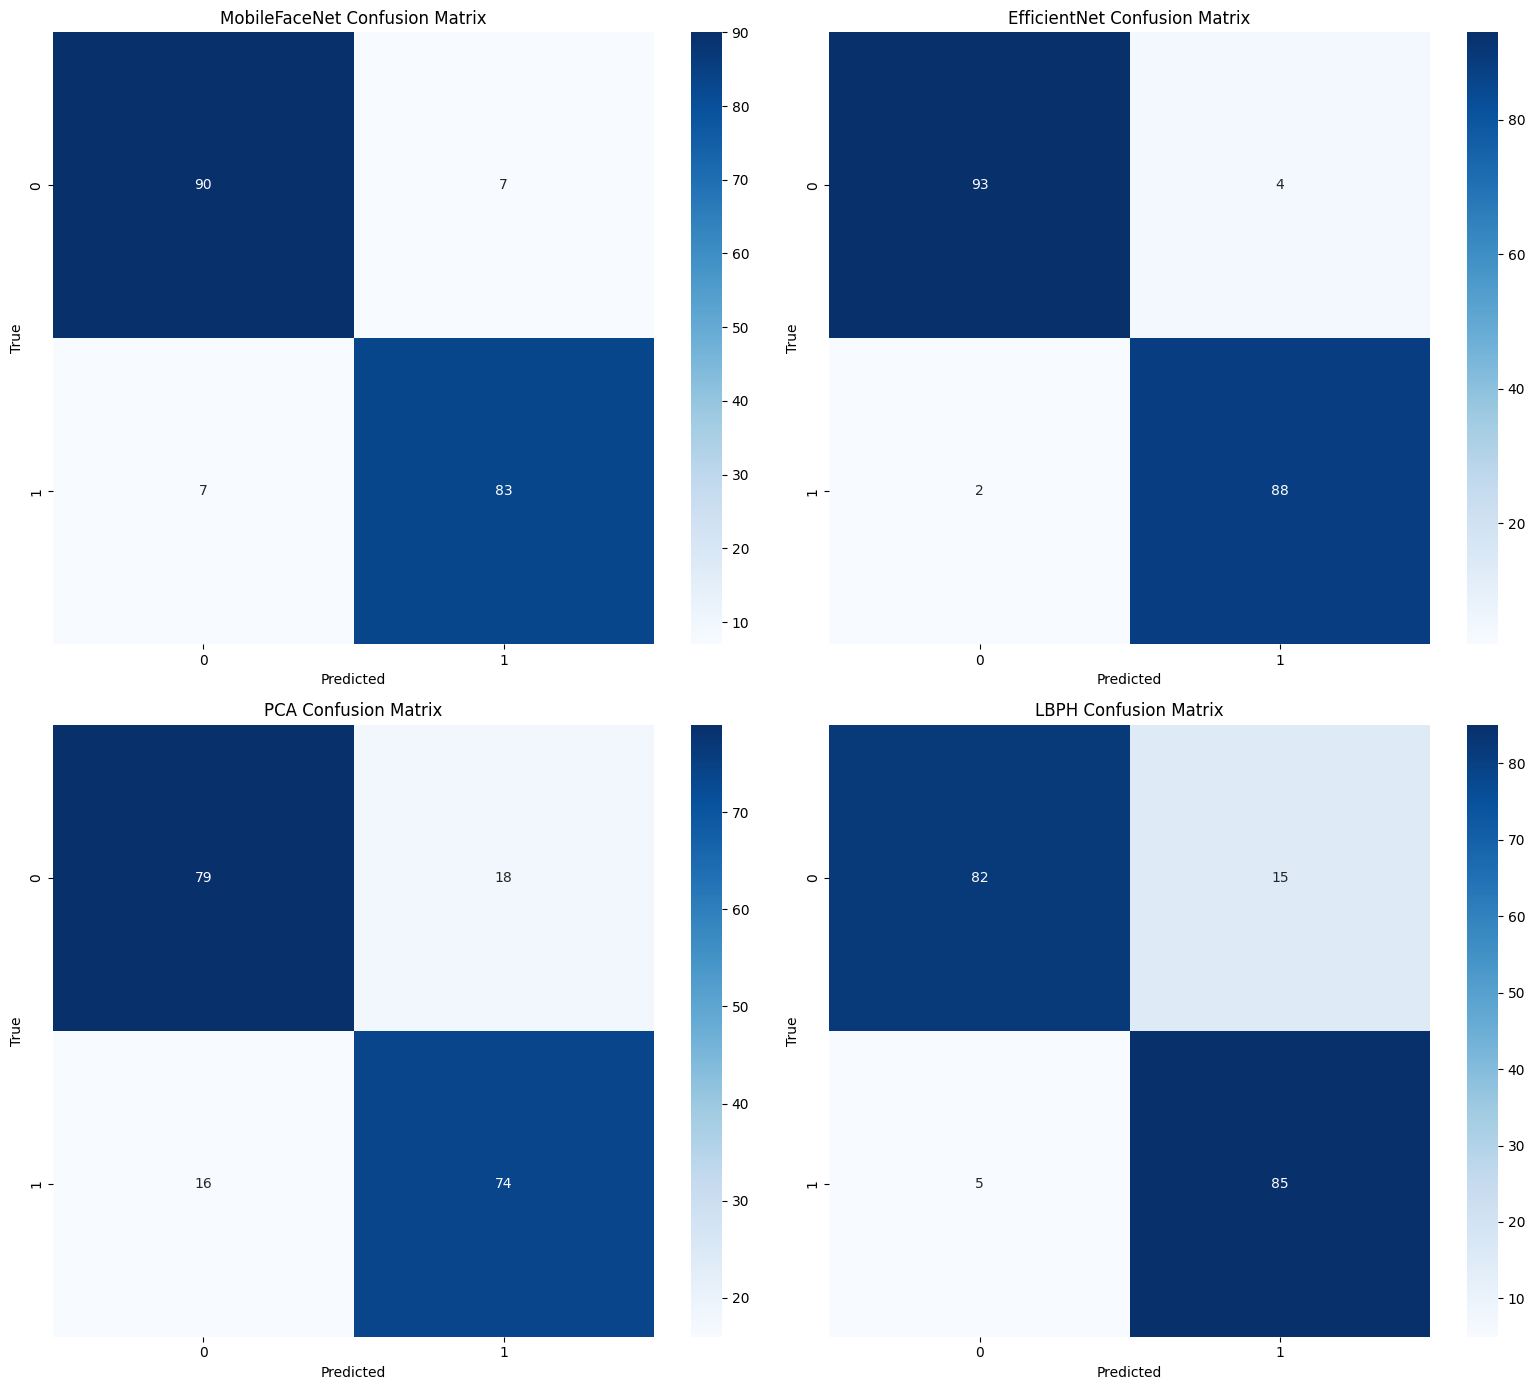

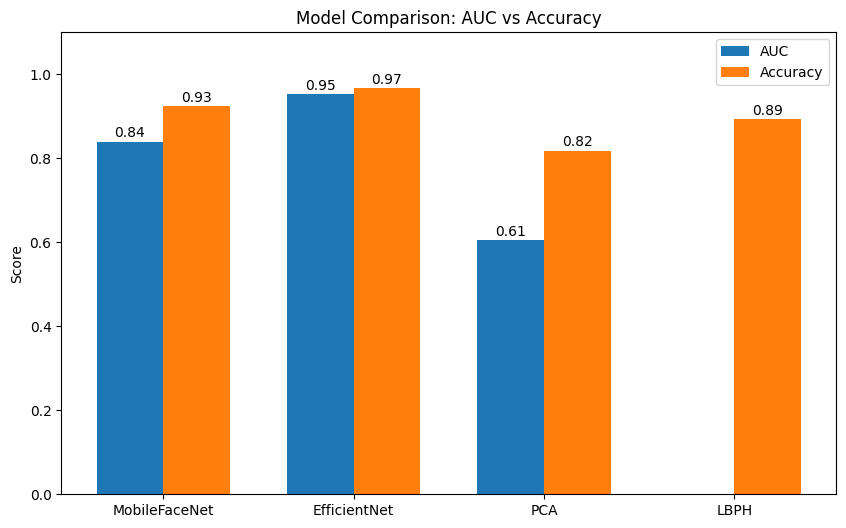

Final Metrics Table:
Model                | AUC        | Accuracy  
--------------------------------------------------
MobileFaceNet        | 0.8396     | 0.9251
EfficientNet         | 0.9523     | 0.9679
PCA                  | 0.6051     | 0.8182
LBPH                 | 0.0000     | 0.8930


In [ ]:
# 1. ROC Curves
plt.figure(figsize=(10, 8))
for name, res in results.items():
    if name == "LBPH": continue 
    plt.plot(res['fpr'], res['tpr'], label=f"{name} (AUC = {res['auc']:.4f})")
    
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Face Recognition Models')
plt.legend()
plt.show()

# 2. Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = res['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name} Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.show()

# 3. Model Comparison Bar Chart
models = list(results.keys())
aucs = [results[m]['auc'] for m in models]
accs = [results[m]['acc'] for m in models]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, aucs, width, label='AUC')
plt.bar(x + width/2, accs, width, label='Accuracy')
plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Model Comparison: AUC vs Accuracy')
plt.legend()
plt.ylim(0, 1.1)
for i, v in enumerate(aucs):
    if models[i] != 'LBPH':
        plt.text(i - width/2, v + 0.01, f'{v:.2f}', ha='center')
    else:
        plt.text(i - width/2, 0.05, 'N/A', ha='center', color='white')
        
for i, v in enumerate(accs):
    plt.text(i + width/2, v + 0.01, f'{v:.2f}', ha='center')

plt.show()

print("Final Metrics Table:")
print(f"{'Model':<20} | {'AUC':<10} | {'Accuracy':<10}")
print("-" * 50)
for name, res in results.items():
    auc_val = res.get('auc', 0)
    acc_val = res.get('acc', 0)
    print(f"{name:<20} | {auc_val:.4f}     | {acc_val:.4f}")



## Analysis of Results

**Why is PCA performance lower?**
* **Holistic Nature**: PCA (Eigenfaces) looks at the entire image as a single vector. It is extremely sensitive to global variations like lighting changes, shadows, and even slight misalignments.
* **Linearity**: It assumes face variations lie on a linear subspace, which is not true for complex pose/expression changes.
* **Comparison**: MobileFaceNet and EfficientNet use Deep Convolutional Networks (CNNs) that learn **invariant features** (like shapes, textures) that ignore lighting. LBPH uses **local** binary patterns which are also robust to global lighting changes. Hence, PCA is expected to be the weakest in this modern comparison.

